<img src="https://www.unad.edu.co/images/footer/logo-unad-acreditacion-min.png" width="780" height="140" align="right"/>

<p style="text-align: center;"> Curso: Visualización para la Analítica de Datos</p>

<p style="text-align: center;"> Grupo: 01 </p>

<p style="text-align: center;"> Tarea 02 - Componente práctico del Curso</p>

<p style="text-align: center;">  Estudiante: Jerónimo Ramos Ruiz </p>

<p style="text-align: center;">  Tutor: </p>

<p style="text-align: center;"> UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA - UNAD </p>

<p style="text-align: center;"> Medellín, Septiembre 2026</p>

In [27]:
import importlib
import subprocess
import sys

librerias_proyecto = {"numpy": "numpy",
             "pandas": "pandas",
             "matplotlib":"matplotlib",
             "seaborn":"seaborn",
             "openpyxl": "openpyxl",
             "geopandas": "geopandas",
             "folium": "folium",
             "shapely": "shapely",
             "requests": "requests"
             }
             
print("====== INICIANDO VERIFICACIÓN DE ENTORNO ======\n")

# 2. Recorrer y validar cada librería de la lista
for nombre_importar, nombre_pip in librerias_proyecto.items():
    instalada = False
    
    while not instalada:
        try:
            # Intenta cargar la librería dinámicamente
            modulo = importlib.import_module(nombre_importar)
            instalada = True
            
            # Obtener la versión de forma segura
            version = getattr(modulo, "__version__", "Versión no expuesta")
            print(f"[{nombre_importar}] Lista para usar. Versión: {version}")
            
        except ImportError:
            print(f"[{nombre_importar}] No encontrada. Instalando vía pip: '{nombre_pip}'...")
            try:
                # Instala usando el entorno de Python que está ejecutando el script
                subprocess.check_call([sys.executable, "-m", "pip", "install", nombre_pip])
                print(f"[{nombre_importar}] Instalación enviada. Validando acceso...")
            except subprocess.CalledProcessError:
                print(f"[ERROR CRÍTICO] Falló la instalación de '{nombre_pip}'.")
                print("Revisa tu conexión a internet o los permisos de administrador.\n")
                break  # Rompe el ciclo while de esta librería para pasar a la siguiente

print("\n====== PROCESO DE CONFIGURACIÓN FINALIZADO ======")


====== INICIANDO VERIFICACIÓN DE ENTORNO ======

[numpy] Lista para usar. Versión: 2.4.3
[pandas] Lista para usar. Versión: 3.0.1
[matplotlib] Lista para usar. Versión: 3.11.1
[seaborn] Lista para usar. Versión: 0.13.2
[openpyxl] Lista para usar. Versión: 3.1.5
[geopandas] No encontrada. Instalando vía pip: 'geopandas'...
[geopandas] Instalación enviada. Validando acceso...
[geopandas] Lista para usar. Versión: 1.1.4
[folium] No encontrada. Instalando vía pip: 'folium'...
[folium] Instalación enviada. Validando acceso...
[folium] Lista para usar. Versión: 0.20.0
[shapely] Lista para usar. Versión: 2.1.2
[requests] Lista para usar. Versión: 2.33.1

====== PROCESO DE CONFIGURACIÓN FINALIZADO ======


In [1]:
# ==============================================================================
# 0. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN DEL ENTORNO
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import geopandas as gpd
import requests
from shapely.geometry import Point
import zipfile

# Configuración para que los gráficos se muestren inline y con un estilo limpio
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Importación de los datos

In [2]:
# 1. Obtenemos la ruta de la carpeta actual donde está tu notebook
carpeta_actual = Path('.').resolve()

# 2. Subimos un nivel en la estructura de carpetas (una carpeta por encima)
carpeta_superior = carpeta_actual.parent


In [3]:
# 3. Construimos la ruta relativa exacta hacia tu archivo de Excel
ruta_archivo = carpeta_superior / 'data/Anexo 1 - dataset fase 2.xlsx'

print(f"Buscando el archivo en la ruta: {ruta_archivo}")

# 4. Importamos el archivo de Excel a un DataFrame de Pandas
try:
    df_original = pd.read_excel(ruta_archivo, index_col=0, usecols=lambda column: column != 'ID')
    print("¡Archivo importado con éxito!")
    print(f"Dimensiones del dataset: {df_original.shape}")
except FileNotFoundError:
    print("Error: No se encontró el archivo. Verifica que el nombre sea exacto.")
except Exception as e:
    print(f"Ocurrió un error al leer el archivo: {e}")

Buscando el archivo en la ruta: D:\Jeronimo\02. Estudios\02. Posgrado\01. UNAD - Maestría en Ciencia de Datos\04. Sem 3\03. Visualización\02. Fase 02\data\Anexo 1 - dataset fase 2.xlsx
¡Archivo importado con éxito!
Dimensiones del dataset: (1000, 7)


In [4]:
ruta_zip = carpeta_actual.parent / "data/COLOMBIA.zip" 
carpeta_extraccion = carpeta_actual / "mapa_temporal"


print(f"Buscando el mapa base en: {ruta_zip}")

try:
    # 1. Descomprimimos el archivo ZIP de manera segura
    with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
        zip_ref.extractall(carpeta_extraccion)
    print("-> Archivo ZIP descomprimido con éxito en la carpeta temporal.")
    
    # 2. Buscamos automáticamente el archivo .shp dentro de la carpeta extraída
    archivos_shp = list(carpeta_extraccion.glob("**/*.shp"))
    
    if not archivos_shp:
        raise FileNotFoundError("No se encontró ningún archivo con extensión .shp dentro del ZIP.")
        
    ruta_shp_final = archivos_shp[0]
    print(f"-> Archivo cartográfico detectado: {ruta_shp_final.name}")

    # 2. Leemos el Shapefile
    mapa_local = gpd.read_file(str(ruta_shp_final))
    print("¡Shapefile cargado con éxito en GeoPandas!")
    
    # a. Inspeccionamos las primeras filas para saber cómo se llaman tus columnas
    print("\nColumnas disponibles en tu Shapefile:")
    print(mapa_local.columns.tolist())
    
    # 3. Homologamos el nombre de la columna de departamento
    columna_departamento_shp = 'DPTO_CNMBR' 
    mapa_local = mapa_local[[columna_departamento_shp, 'geometry']].rename(
        columns={columna_departamento_shp: 'departamento'}
    )
    
    # 4. Forzamos el sistema de coordenadas geográficas estándar (WGS84) para evitar desajustes
    if mapa_local.crs is None or mapa_local.crs.to_epsg() != 4326:
        mapa_local = mapa_local.to_crs(epsg=4326)

except FileNotFoundError:
    print(f"Error: No se encontró el archivo ZIP en la ruta especificada: {ruta_zip}")
except Exception as e:
    print(f"Ocurrió un error al procesar el Shapefile: {e}")

Buscando el mapa base en: D:\Jeronimo\02. Estudios\02. Posgrado\01. UNAD - Maestría en Ciencia de Datos\04. Sem 3\03. Visualización\02. Fase 02\data\COLOMBIA.zip
-> Archivo ZIP descomprimido con éxito en la carpeta temporal.
-> Archivo cartográfico detectado: COLOMBIA.shp
¡Shapefile cargado con éxito en GeoPandas!

Columnas disponibles en tu Shapefile:
['OBJECTID', 'DPTO_CCDGO', 'DPTO_NANO_', 'DPTO_CNMBR', 'DPTO_CACTO', 'DPTO_NAREA', 'DPTO_CSMBL', 'DPTO_NANO', 'PAIS_PAIS_', 'SHAPE_Leng', 'SHAPE_Area', 'geometry']


---
# Actividad 1: Preparación del dataset y Análisis Exploratorio de Datos


In [5]:
# ==============================================================================
# 1. EXPLORACIÓN INICIAL DEL DATASET
# ==============================================================================
print("--- 1. EXPLORACIÓN INICIAL ---")
print(f"Dimensiones del dataset original: {df_original.shape}\n")
print("Primeros 5 registros:")
display(df_original.head())

print("\nInformación general del tipo de datos:")
df_original.info()

print("\nConteo de valores nulos por columna:")
print(df_original.isnull().sum())

--- 1. EXPLORACIÓN INICIAL ---
Dimensiones del dataset original: (1000, 7)

Primeros 5 registros:


,Nombre,Categoría,Calificación,Precio promedio (USD),Número de reseñas,Latitud,Longitud
index,,,,,,,
0,Restaurante 1,China,4.8,38,344,4.67,-74.14
1,Restaurante 2,Francesa,4.2,14,264,3.60,-75.60
2,Restaurante 3,Francesa,3.3,21,252,5.83,-76.09
3,Restaurante 4,Peruana,3.6,22,299,6.26,-74.45
4,Restaurante 5,Italiana,4.7,31,411,4.49,-75.74



Información general del tipo de datos:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Nombre                 1000 non-null   str    
 1   Categoría              1000 non-null   str    
 2   Calificación           1000 non-null   float64
 3   Precio promedio (USD)  1000 non-null   int64  
 4   Número de reseñas      1000 non-null   int64  
 5   Latitud                1000 non-null   float64
 6   Longitud               1000 non-null   float64
dtypes: float64(3), int64(2), str(2)
memory usage: 54.8 KB

Conteo de valores nulos por columna:
Nombre                   0
Categoría                0
Calificación             0
Precio promedio (USD)    0
Número de reseñas        0
Latitud                  0
Longitud                 0
dtype: int64


In [6]:
# ==============================================================================
# 2. LIMPIEZA DE DATOS Y SELECCIÓN DE VARIABLES
# ==============================================================================
print("\n--- 2. PROCESO DE LIMPIEZA ---")

# a. Eliminamos duplicados exactos
df_clean = df_original.drop_duplicates().copy()
print(f"Registros después de eliminar duplicados: {df_clean.shape[0]}")

# b. Asingación del departamento
# 1. Convertimos a tipo numérico forzando errores a NaN (por si vienen textos o espacios)
df_clean['Latitud'] = pd.to_numeric(df_clean['Latitud'], errors='coerce')
df_clean['Longitud'] = pd.to_numeric(df_clean['Longitud'], errors='coerce')

# 2. Registramos cuántos datos nulos iniciales o corruptos hay en coordenadas
nulos_coordenadas = df_clean[['Latitud', 'Longitud']].isnull().any(axis=1).sum()
print(f"Registros con coordenadas nulas o texto no válido: {nulos_coordenadas}")

# 3. Definimos los límites geográficos oficiales de Colombia
LAT_MIN, LAT_MAX = -4.5, 13.5
LON_MIN, LON_MAX = -79.0, -66.5

# 4. Creamos los filtros para mantener solo los datos correctos
filtro_latitud = (df_clean['Latitud'] >= LAT_MIN) & (df_clean['Latitud'] <= LAT_MAX)
filtro_longitud = (df_clean['Longitud'] >= LON_MIN) & (df_clean['Longitud'] <= LON_MAX)

# Combinamos ambos filtros. Los registros válidos deben cumplir ambas condiciones.
registros_antes = df_clean.shape[0]
df_clean = df_clean[filtro_latitud & filtro_longitud].copy()
registros_despues = df_clean.shape[0]

print(f"Registros eliminados por estar fuera de las fronteras de Colombia: {registros_antes - registros_despues}")
print(f"Registros listos y validados geográficamente: {df_clean.shape[0]}")

print("¡Limpieza completada! Datos listos para el análisis.")


--- 2. PROCESO DE LIMPIEZA ---
Registros después de eliminar duplicados: 1000
Registros con coordenadas nulas o texto no válido: 0
Registros eliminados por estar fuera de las fronteras de Colombia: 5
Registros listos y validados geográficamente: 995
¡Limpieza completada! Datos listos para el análisis.


In [7]:
# 5. Convertimos el DataFrame de restaurantes en un GeoDataFrame
geometria = [Point(xy) for xy in zip(df_clean['Longitud'], df_clean['Latitud'])]
gdf_restaurantes = gpd.GeoDataFrame(df_clean, geometry=geometria, crs="EPSG:4326")

# 6. Ejecutamos la Unión Espacial (Spatial Join)
df_con_departamento = gpd.sjoin(gdf_restaurantes, mapa_local, how="left", predicate="within")

# Limpiamos las columnas del join
if 'index_right' in df_con_departamento.columns:
    df_con_departamento = df_con_departamento.drop(columns=['index_right'])
    
df_clean = pd.DataFrame(df_con_departamento)
print("\n¡Departamentos asignados correctamente usando tu SHP local!")
display(df_clean[['Nombre', 'Latitud', 'Longitud', 'departamento']].head())


¡Departamentos asignados correctamente usando tu SHP local!


,Nombre,Latitud,Longitud,departamento
index,,,,
0,Restaurante 1,4.67,-74.14,BOGOTA D.C.
1,Restaurante 2,3.60,-75.60,TOLIMA
2,Restaurante 3,5.83,-76.09,ANTIOQUIA
3,Restaurante 4,6.26,-74.45,SANTANDER
4,Restaurante 5,4.49,-75.74,QUINDIO


In [8]:
# ==============================================================================
# 3. ANÁLISIS ESTADÍSTICO DESCRIPTIVO
# ==============================================================================
print("\n--- 3. ANÁLISIS ESTADÍSTICO DESCRIPTIVO ---")
# Estadísticas de las variables numéricas
variables_numericas = ['Calificación', 'Precio promedio (USD)', 'Número de reseñas']
resumen_descriptivo = df_clean[variables_numericas].describe().T
display(resumen_descriptivo)


--- 3. ANÁLISIS ESTADÍSTICO DESCRIPTIVO ---


,count,mean,std,min,25%,50%,75%,max
Calificación,995.0,2.983015,1.161611,1.0,2.0,3.0,4.0,5.0
Precio promedio (USD),995.0,31.899497,47.396291,-10.0,20.0,29.0,40.0,1000.0
Número de reseñas,995.0,271.761809,129.777020,50.0,159.5,270.0,385.5,499.0


In [13]:
# a. Filtro adicional luego de identificar el valor mínimo del precio
precios_negativos = len(df_clean[df_clean['Precio promedio (USD)'] < 0])
print(f"Registros con precios negativos: {precios_negativos}")

filtro_precio = (df_clean['Precio promedio (USD)'] > 0)

df_clean = df_clean[filtro_precio].copy()

Registros con precios negativos: 2


In [14]:
# Repetimos el análisis descriptivo eliminando las variables negativas
print("\n--- 3. ANÁLISIS ESTADÍSTICO DESCRIPTIVO ---")
# Estadísticas de las variables numéricas
variables_numericas = ['Calificación', 'Precio promedio (USD)', 'Número de reseñas']
resumen_descriptivo = df_clean[variables_numericas].describe().T
display(resumen_descriptivo)


--- 3. ANÁLISIS ESTADÍSTICO DESCRIPTIVO ---


,count,mean,std,min,25%,50%,75%,max
Calificación,993.0,2.983686,1.160860,1.0,2.0,3.0,4.0,5.0
Precio promedio (USD),993.0,31.978852,47.410852,10.0,20.0,29.0,40.0,1000.0
Número de reseñas,993.0,271.590131,129.846801,50.0,159.0,269.0,386.0,499.0



--- 4. GENERANDO VISUALIZACIONES ---


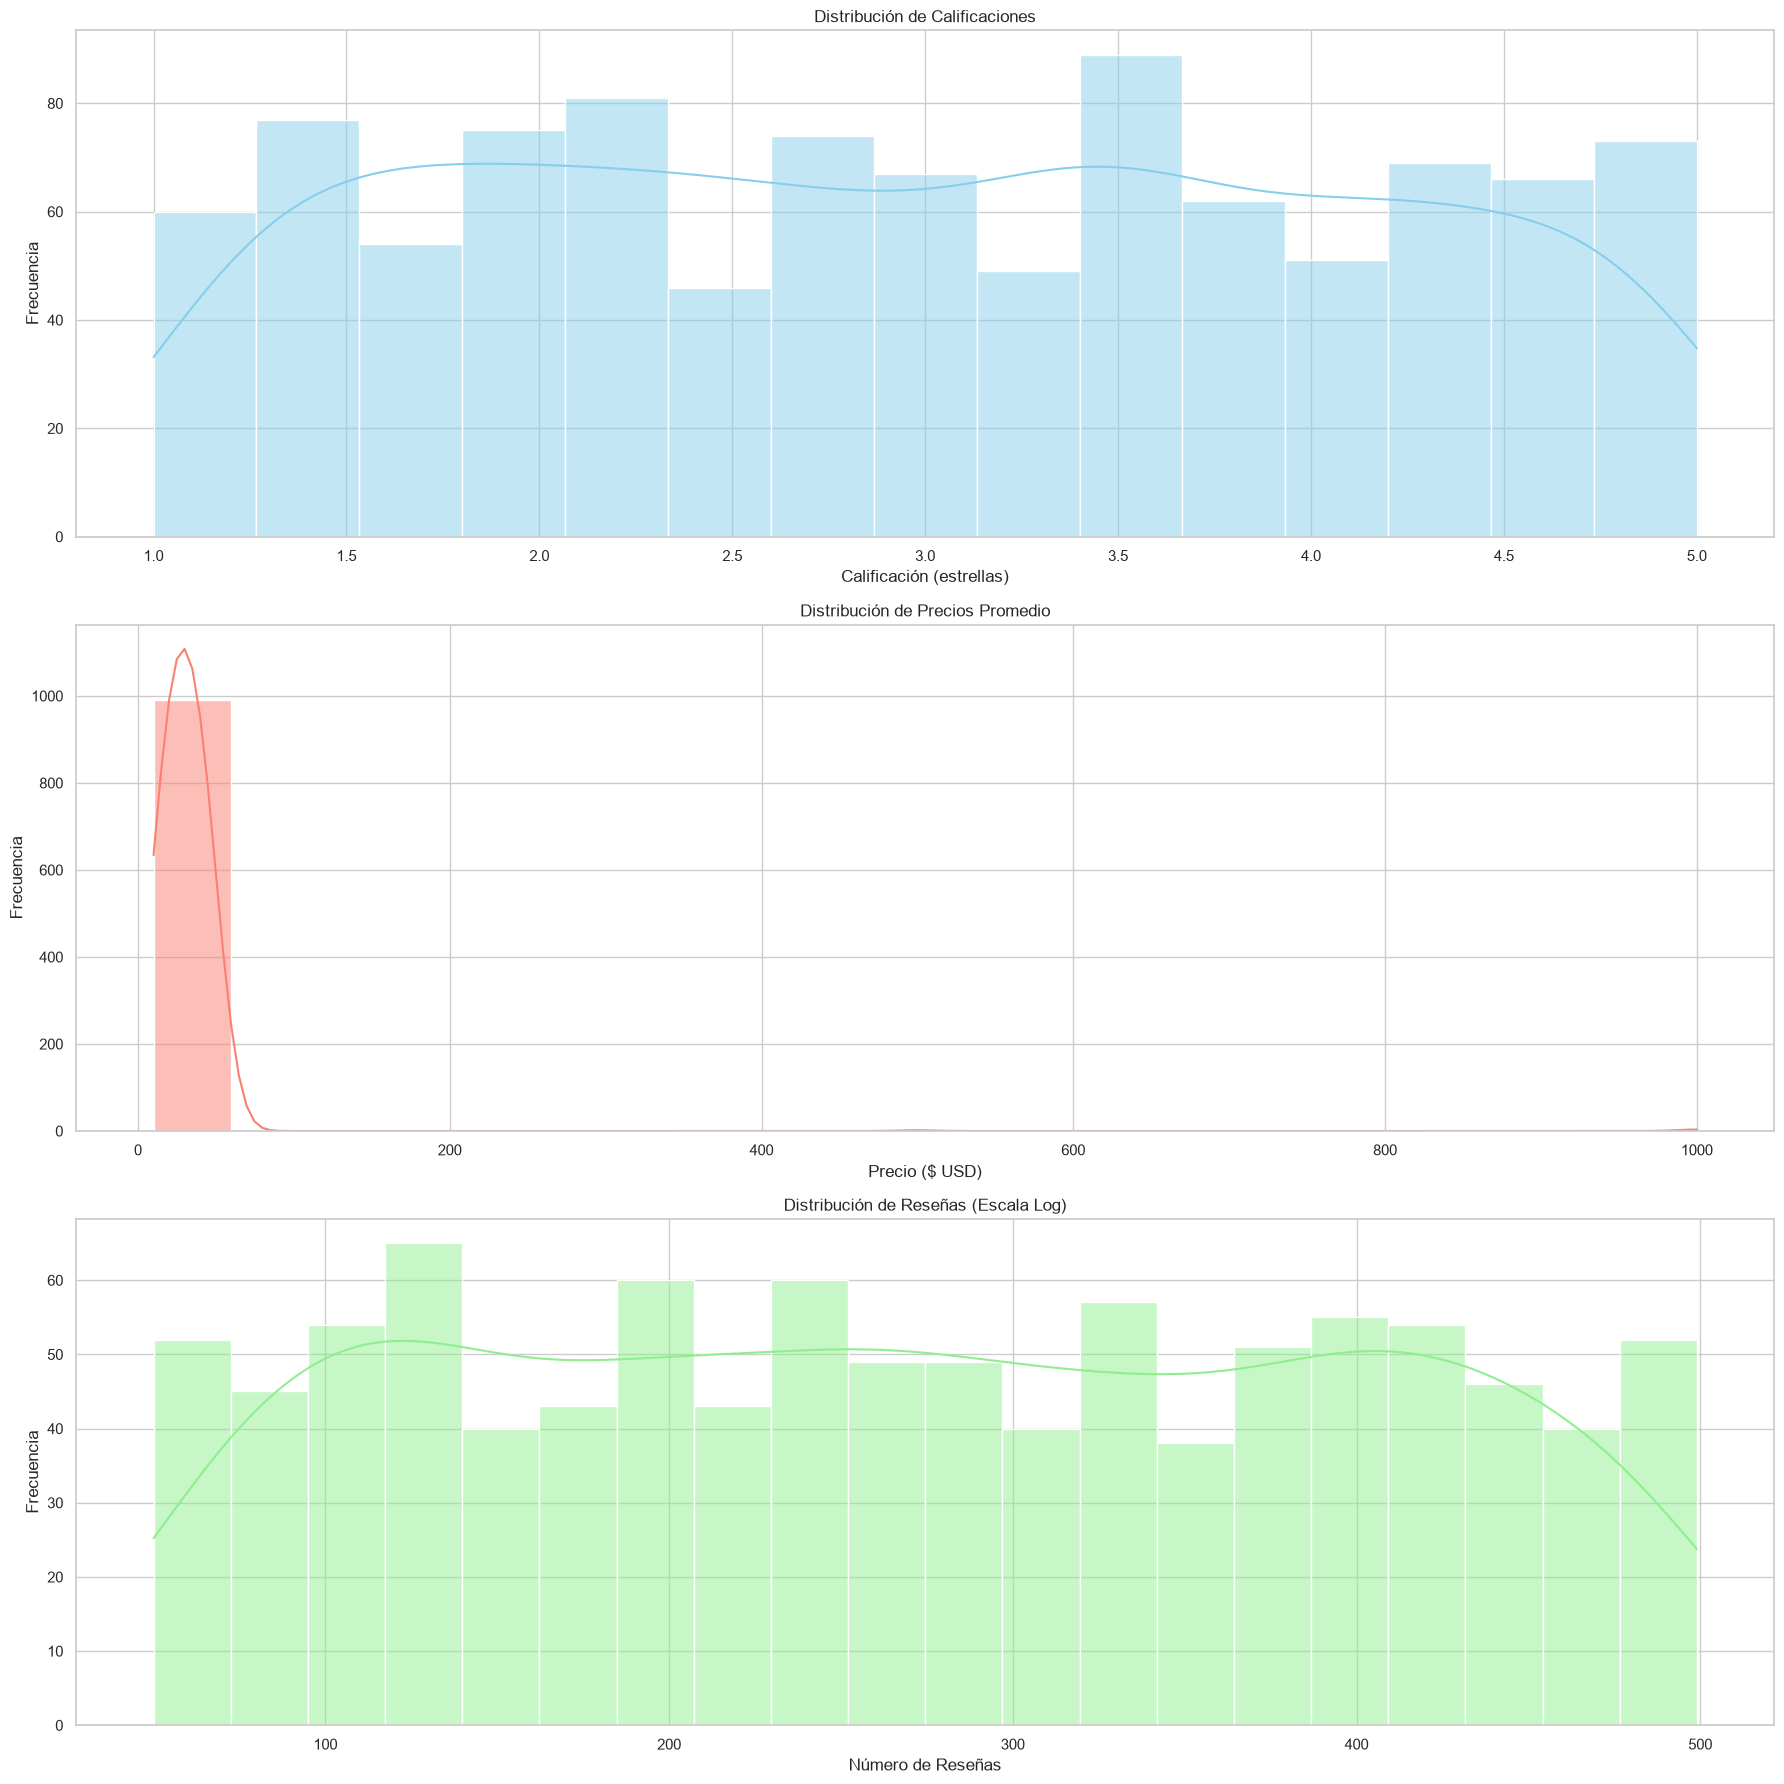

In [ ]:
# ==============================================================================
# 4. VISUALIZACIONES CON MATPLOTLIB Y SEABORN
# ==============================================================================
print("\n--- 4. GENERANDO VISUALIZACIONES ---")

# Crear una figura compuesta (3 subgráficos en una fila para las distribuciones)
fig, axes = plt.subplots(3, 1, figsize=(18, 18))

# Gráfico 1: Distribución de Calificaciones
sns.histplot(df_clean['Calificación'], bins=15, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de Calificaciones')
axes[0].set_xlabel('Calificación (estrellas)')
axes[0].set_ylabel('Frecuencia')

# Gráfico 2: Distribución de Precios Promedio
sns.histplot(df_clean['Precio promedio (USD)'], bins=20, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribución de Precios Promedio')
axes[1].set_xlabel('Precio ($ USD)')
axes[1].set_ylabel('Frecuencia')

# Gráfico 3: Distribución de Número de Reseñas
sns.histplot(df_clean['Número de reseñas'], bins=20, kde=True, color='lightgreen', ax=axes[2])
axes[2].set_title('Distribución de Reseñas (Escala Log)')
axes[2].set_xlabel('Número de Reseñas')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [20]:
# ==============================================================================
# 5. CATEGORÍAS DE COMIDA MÁS POPULARES
# ==============================================================================
print("\nCategorías de Comida más Populares:")
top_categorias = df_clean['Categoría'].value_counts()

# Desplegamos el Top 5 con su respectivo porcentaje del total
for i, (cat, conteo) in enumerate(top_categorias.head(5).items(), 1):
    porcentaje = (conteo / len(df_clean)) * 100
    print(f"   {i}. {cat}: {conteo} restaurantes ({porcentaje:.1f}%)")


# ==============================================================================
# 6. DEPARTAMENTOS CON MAYOR CONCENTRACIÓN DE RESTAURANTES
# ==============================================================================
print("\nConcentración por Departamento:")
top_departamentos = df_clean['departamento'].value_counts()

# Desplegamos el ranking de departamentos
for i, (dpto, conteo) in enumerate(top_departamentos.items(), 1):
    porcentaje = (conteo / len(df_clean)) * 100
    print(f"   {i}. {dpto}: {conteo} establecimientos ({porcentaje:.1f}%)")


Categorías de Comida más Populares:
   1. Peruana: 165 restaurantes (16.6%)
   2. Mexicana: 147 restaurantes (14.8%)
   3. Francesa: 146 restaurantes (14.7%)
   4. China: 144 restaurantes (14.5%)
   5. Italiana: 134 restaurantes (13.5%)

Concentración por Departamento:
   1. TOLIMA: 245 establecimientos (24.7%)
   2. ANTIOQUIA: 171 establecimientos (17.2%)
   3. CUNDINAMARCA: 134 establecimientos (13.5%)
   4. VALLE DEL CAUCA: 105 establecimientos (10.6%)
   5. CALDAS: 85 establecimientos (8.6%)
   6. CHOCO: 75 establecimientos (7.6%)
   7. RISARALDA: 59 establecimientos (5.9%)
   8. QUINDIO: 25 establecimientos (2.5%)
   9. META: 24 establecimientos (2.4%)
   10. SANTANDER: 23 establecimientos (2.3%)
   11. BOGOTA D.C.: 20 establecimientos (2.0%)
   12. BOYACA: 19 establecimientos (1.9%)
   13. HUILA: 8 establecimientos (0.8%)


In [ ]:
import folium
from folium.plugins import MarkerCluster

print("\n--- GENERANDO MAPA INTERACTIVO DE COLOMBIA ---")

# 1. Crear el mapa base centrado geográficamente en Colombia
# Coordenadas aproximadas del centro del país: Lat 4.57, Lon -74.29
mapa_interactivo = folium.Map(location=[4.570868, -74.297333], zoom_start=6, tiles="OpenStreetMap")

# 2. Inicializar el contenedor de agrupamiento (Clustering)
marker_cluster = MarkerCluster().add_to(mapa_interactivo)

# 3. Iterar sobre las filas de tu dataset para añadir cada restaurante al mapa
# Limitamos a los registros que tengan coordenadas válidas no nulas
df_mapa = df_clean.dropna(subset=['Latitud', 'Longitud'])

for idx, fila in df_mapa.iterrows():
    # Crear el texto informativo que saldrá al hacer clic en el pin (Popup)
    html_popup = f"""
    <div style="font-family: Arial, sans-serif; width: 200px;">
        <h4 style="margin-bottom:5px; color:#2c3e50;">{fila['Nombre']}</h4>
        <b>Categoría:</b> {fila['Categoría']}<br>
        <b>Calificación:</b> ⭐ {fila['Calificación']}<br>
        <b>Precio Promedio:</b> ${fila['Precio promedio (USD)']:,.0f} COP<br>
        <b>Ciudad:</b> {fila['departamento']}
    </div>
    """
    popup = folium.Popup(html_popup, max_width=250)
    
    # Determinar el color del pin según su calificación (opcional para darle estilo)
    if fila['Calificación'] >= 4.5:
        color_pin = 'green'
    elif fila['Calificación'] >= 3.5:
        color_pin = 'orange'
    else:
        color_pin = 'red'
        
    # Crear el marcador individual y agregarlo al cluster
    folium.Marker(
        location=[fila['Latitud'], fila['Longitud']],
        popup=popup,
        tooltip=fila['Nombre'], # Texto rápido al pasar el cursor por encima
        icon=folium.Icon(color=color_pin, icon='cutlery', prefix='fa') # Icono de cubiertos
    ).add_to(marker_cluster)

# 4. Desplegar el mapa directamente en la celda del Jupyter Notebook
mapa_interactivo

# Opcional: Si quieres guardarlo como un archivo HTML independiente para compartirlo:
mapa_interactivo.save("mapa_restaurantes_colombia.html")



--- GENERANDO MAPA INTERACTIVO DE COLOMBIA ---
